In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from utils import *
from kmeans import *
from gmm import *
from dbscan import *

In [4]:
ruta = 'data/clustering.csv'
X = cargar_datos(ruta)

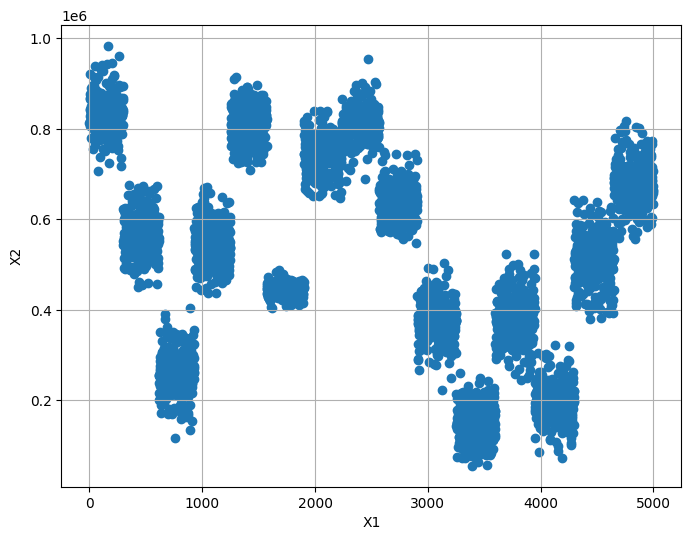

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

In [6]:
# Paso 1: Método del codo
inercias = metodo_del_codo(X, k_max=10)

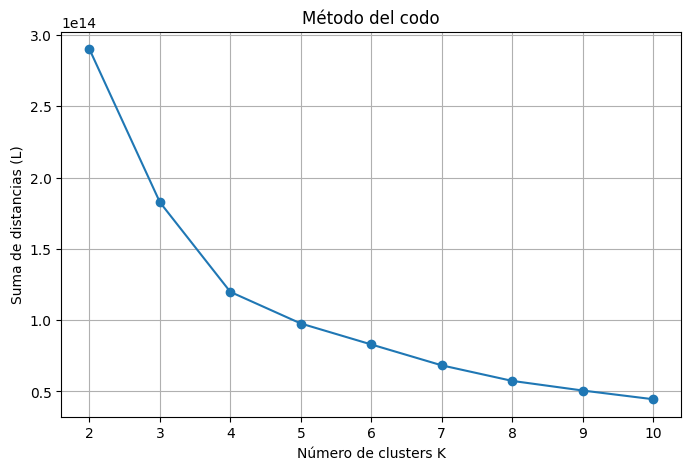

In [7]:
# Extraer solo los valores de inercia para graficar
graficar_metodo_del_codo(inercias, k_max=10)

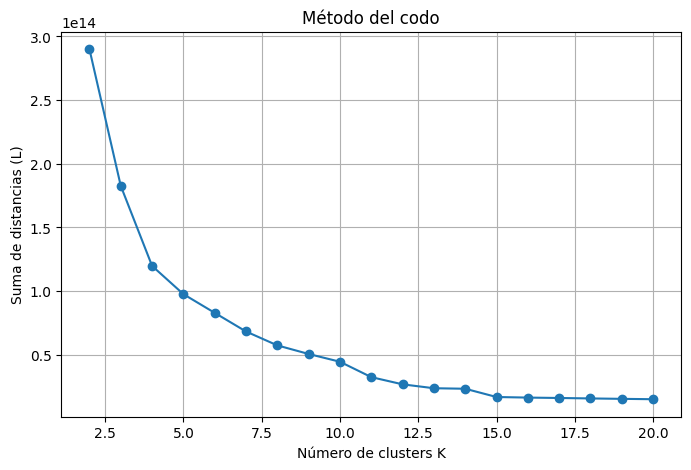

In [8]:

inercias.extend(metodo_del_codo(X,k_min=11,k_max=20))

graficar_metodo_del_codo(inercias, k_max=20)

Inercia final con K=15: 16861880045499.42


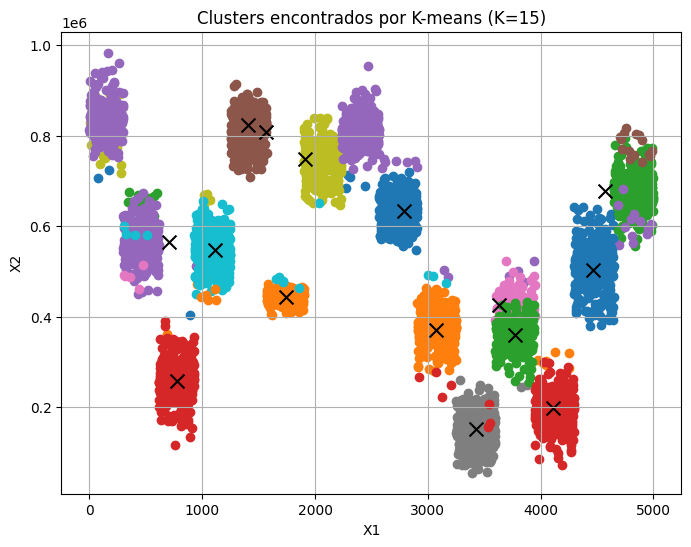

In [9]:
# Paso 2: Elegir K óptimo manualmente
k_opt = 15  # Elegí tras ver el gráfico
centroides, labels, inercia = kmeans(X, k_opt)
print(f'Inercia final con K={k_opt}: {inercia:.2f}')

# Paso 3: Graficar los clusters
graficar_clusters(X, labels, centroides)

Pesos (π): [0.06709981 0.06581316 0.070014   0.0630126  0.06341269 0.06421284
 0.01237957 0.06920423 0.06681336 0.06401279 0.07001382 0.0690138
 0.05764403 0.07001401 0.12733926]
Medias (μ):
[[2.73743256e+03 6.36168483e+05 7.15742098e+05]
 [1.73600000e+03 4.44233194e+05 6.10931886e+05]
 [4.82350000e+03 6.80240246e+05 1.51254086e+05]
 [7.73000000e+02 2.59641565e+05 7.39929765e+05]
 [4.57000083e+02 5.68338141e+05 2.43155970e+05]
 [1.41100000e+03 8.08878850e+05 2.36513589e+05]
 [3.80801191e+03 4.25593673e+05 1.42063975e+05]
 [3.42548767e+03 1.52235084e+05 2.40936334e+05]
 [2.06750000e+03 7.44846701e+05 4.90049198e+05]
 [1.09050002e+03 5.45993362e+05 4.34357882e+05]
 [4.47350045e+03 5.06589031e+05 8.49907324e+05]
 [3.08000000e+03 3.70984290e+05 3.91921985e+05]
 [3.76604508e+03 3.72277925e+05 1.76208553e+05]
 [4.12349994e+03 2.00244002e+05 4.79427082e+05]
 [1.34567606e+03 8.21693514e+05 7.22659327e+05]]


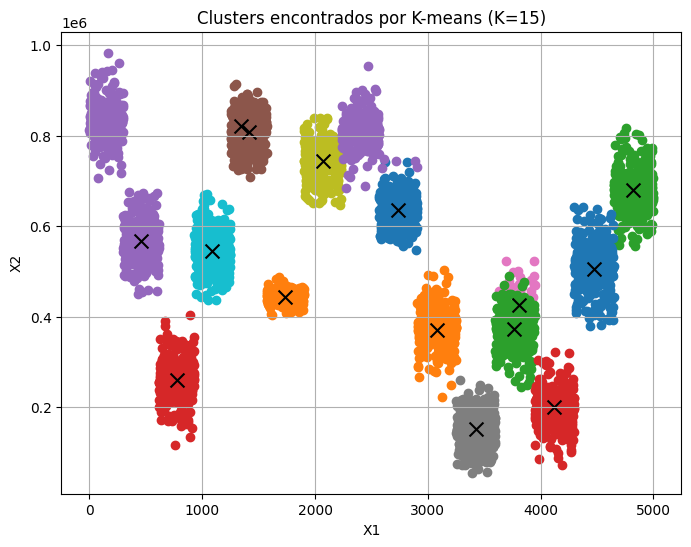

In [10]:
# Probar distintos valores de K (recomendado: usar mismo K que K-means)
k = 15
medias, covarianzas, pesos, labels = gmm(X, k)

print(f'Pesos (π): {pesos}')
print(f'Medias (μ):\n{medias}')

# Visualización
graficar_clusters(X, labels, medias)

Se encontraron 15 clusters


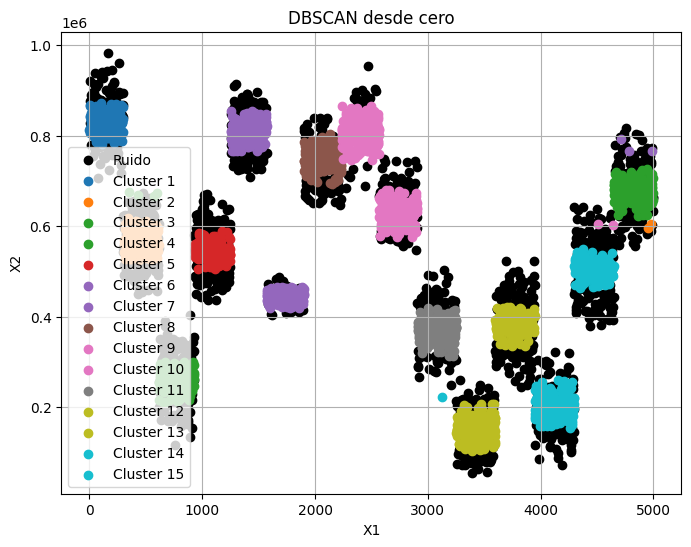

In [11]:
# Parámetros de DBSCAN
eps = 20000
min_pts = 25

etiquetas = dbscan(X, eps, min_pts)
print(f'Se encontraron {len(set(etiquetas)) - (1 if -1 in etiquetas else 0)} clusters')
graficar_dbscan(X, etiquetas)